In [1]:
# =============================================================================
# Notebook 01 — Visão Geral do Dataset
# Sistema de Painéis Hospitalares — Central de ML
# =============================================================================
# Objetivo: primeira inspeção do histórico de chegadas do PS.
# - Validar volume, range de datas, integridade
# - Identificar gaps, anomalias grosseiras
# - Entender o "shape" geral dos dados antes de modelar
# =============================================================================

import os
import sys
import pandas as pd
import numpy as np
import psycopg2
from psycopg2.extras import RealDictCursor
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Sobe um nível pra achar o .env (notebook está em notebooks/, .env em ml_workspace/)
load_dotenv('../.env')

# Configuração visual dos gráficos
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Pandas: mostrar mais colunas e linhas no display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"numpy:  {np.__version__}")
print("Setup OK")

Python: 3.11.9
pandas: 2.2.3
numpy:  1.26.4
Setup OK


In [2]:
# =============================================================================
# Conecta ao PostgreSQL e carrega a tabela completa em um DataFrame
# =============================================================================

conn = psycopg2.connect(
    host=os.getenv('DB_HOST'),
    port=os.getenv('DB_PORT'),
    database=os.getenv('DB_NAME'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD')
)

query = """
    SELECT *
    FROM public.ml_ps_historico_chegadas
    ORDER BY dt_entrada
"""

df = pd.read_sql(query, conn)
conn.close()

print(f"Linhas carregadas: {len(df):,}")
print(f"Colunas: {len(df.columns)}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

C:\Users\tasybi.HSFDF\AppData\Local\Temp\ipykernel_11716\4104744338.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Linhas carregadas: 236,864
Colunas: 37
Memória: 280.6 MB


In [3]:
# =============================================================================
# Visão geral do DataFrame
# =============================================================================

print("=" * 70)
print("COLUNAS E TIPOS")
print("=" * 70)
print(df.dtypes)

print()
print("=" * 70)
print("PRIMEIRAS 3 LINHAS")
print("=" * 70)
df.head(3)

COLUNAS E TIPOS
nr_atendimento                    int64
dt_entrada               datetime64[ns]
dt_entrada_str                   object
ano_entrada                       int64
mes_entrada                       int64
dia_entrada                       int64
hora_entrada                      int64
min_entrada                       int64
dia_semana                        int64
nm_dia_semana                    object
cd_setor_atendimento              int64
ds_setor_atendimento             object
ie_prioridade                     int64
ds_triagem                       object
dt_fim_triagem           datetime64[ns]
ds_nivel_urgencia                object
ie_sexo                          object
qt_idade                          int64
dt_nascimento                    object
cd_pessoa_fisica                 object
ds_convenio                      object
ie_clinica                        int64
ds_clinica                       object
dt_inicio_atendimento    datetime64[ns]
dt_atend_medico         

,nr_atendimento,dt_entrada,dt_entrada_str,ano_entrada,mes_entrada,dia_entrada,hora_entrada,min_entrada,dia_semana,nm_dia_semana,cd_setor_atendimento,ds_setor_atendimento,ie_prioridade,ds_triagem,dt_fim_triagem,ds_nivel_urgencia,ie_sexo,qt_idade,dt_nascimento,cd_pessoa_fisica,ds_convenio,ie_clinica,ds_clinica,dt_inicio_atendimento,dt_atend_medico,dt_fim_consulta,dt_alta,dt_cancelamento,ie_status,ie_internado,cd_cid_principal,cd_cid_secundario,ds_bairro,cd_municipio_ibge,ie_cancelado,dt_extracao,dt_carga_pg
0,2171041,2023-07-14 03:34:10,2023-07-14 03:34:10,2023,7,14,3,34,6,SEXTA-FEIRA,119,Classificação de Risco,999,None,2023-07-14 11:33:59,Não informado,M,47,1975-07-20,584936,UNIMED BRASÍLIA - 0865,1,Clinica Médica,2023-07-14 06:55:13,2023-07-14 03:41:55,2023-07-14 03:45:47,2023-07-14 15:34:10,NaT,AL,S,N20,None,AGUAS LINDAS,None,N,2026-04-09 04:30:24,2026-04-09 04:31:32.795574
1,2171043,2023-07-14 04:10:50,2023-07-14 04:10:50,2023,7,14,4,10,6,SEXTA-FEIRA,119,Classificação de Risco,999,None,2023-07-14 04:27:11,Não informado,F,8,2015-02-21,146998,GAMA SAUDE,10,Pediatria,2023-07-14 04:57:26,2023-07-14 04:16:52,2023-07-14 04:24:31,2023-07-14 16:10:50,NaT,AL,S,R11,None,CEILANDIA,520870,N,2026-04-09 04:30:24,2026-04-09 04:31:32.795574
2,2171045,2023-07-14 04:14:46,2023-07-14 04:14:46,2023,7,14,4,14,6,SEXTA-FEIRA,119,Classificação de Risco,999,None,NaT,Não informado,F,33,1989-09-27,146868,BRADESCO SAÚDE,1,Clinica Médica,NaT,2023-07-14 04:21:03,2023-07-14 04:55:33,2023-07-14 06:45:25,NaT,AL,N,M791,None,Ceilândia Sul Ceilândia,None,N,2026-04-09 04:30:24,2026-04-09 04:31:32.795574


In [4]:
# =============================================================================
# Cobertura temporal
# =============================================================================

print("=" * 70)
print("RANGE TEMPORAL")
print("=" * 70)
print(f"Primeira entrada: {df['dt_entrada'].min()}")
print(f"Última entrada:   {df['dt_entrada'].max()}")
print(f"Duração total:    {(df['dt_entrada'].max() - df['dt_entrada'].min()).days} dias")
print()
print(f"Média de chegadas/dia: {len(df) / ((df['dt_entrada'].max() - df['dt_entrada'].min()).days):.1f}")

RANGE TEMPORAL
Primeira entrada: 2023-07-14 03:34:10
Última entrada:   2026-04-09 01:41:06
Duração total:    999 dias

Média de chegadas/dia: 237.1


In [5]:
# =============================================================================
# % de preenchimento por coluna — pra identificar campos majoritariamente nulos
# =============================================================================

preenchimento = pd.DataFrame({
    'nao_nulos': df.notna().sum(),
    'pct_preenchido': (df.notna().sum() / len(df) * 100).round(1),
    'valores_unicos': df.nunique()
}).sort_values('pct_preenchido', ascending=False)

print("PREENCHIMENTO E CARDINALIDADE DAS COLUNAS")
print("=" * 70)
preenchimento

PREENCHIMENTO E CARDINALIDADE DAS COLUNAS


,nao_nulos,pct_preenchido,valores_unicos
nr_atendimento,236864,100.0,236864
ds_nivel_urgencia,236864,100.0,11
dt_extracao,236864,100.0,1
ie_cancelado,236864,100.0,1
ds_bairro,236766,100.0,2399
ie_internado,236864,100.0,2
ie_status,236864,100.0,8
dt_alta,236849,100.0,236484
ds_clinica,236864,100.0,20
ie_clinica,236864,100.0,20


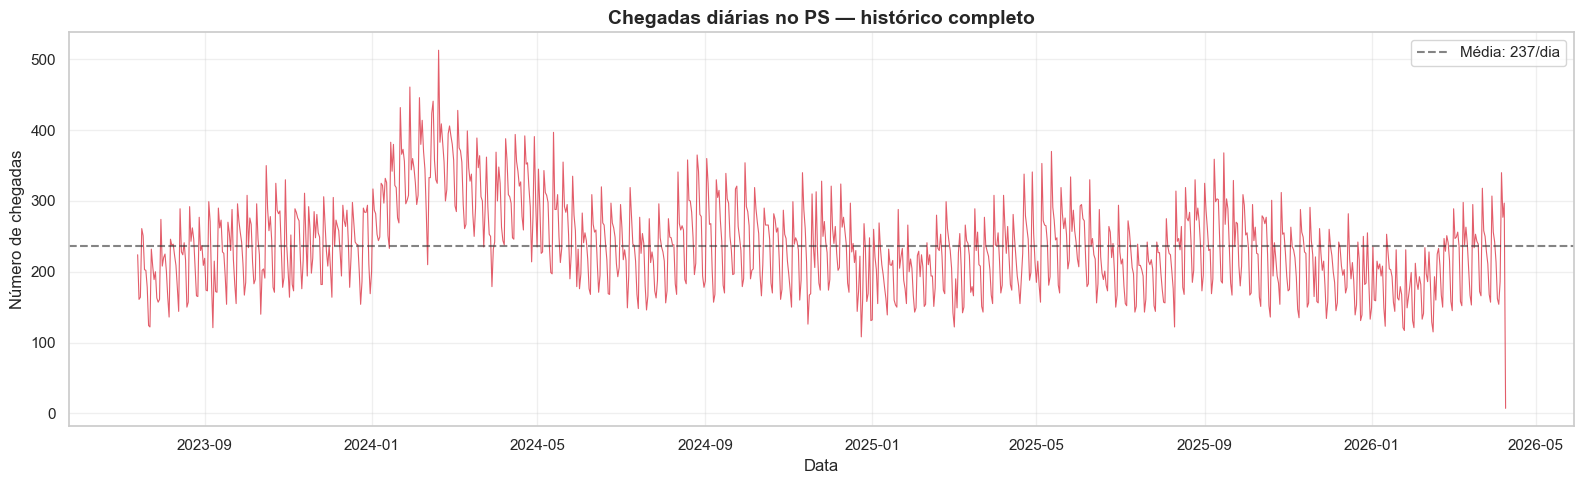


Estatísticas de chegadas/dia:
count    1001.0
mean      236.6
std        62.7
min         7.0
25%       188.0
50%       232.0
75%       276.0
max       513.0
Name: chegadas, dtype: float64


In [6]:
# =============================================================================
# Chegadas por dia — série temporal completa
# =============================================================================

# Agrupa por data (ignora hora)
chegadas_diarias = df.groupby(df['dt_entrada'].dt.date).size().reset_index(name='chegadas')
chegadas_diarias['dt_entrada'] = pd.to_datetime(chegadas_diarias['dt_entrada'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(chegadas_diarias['dt_entrada'], chegadas_diarias['chegadas'],
        linewidth=0.8, color='#dc3545', alpha=0.8)
ax.set_title('Chegadas diárias no PS — histórico completo', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Número de chegadas')
ax.grid(True, alpha=0.3)

# Linha da média
media = chegadas_diarias['chegadas'].mean()
ax.axhline(media, color='#333', linestyle='--', alpha=0.6, label=f'Média: {media:.0f}/dia')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nEstatísticas de chegadas/dia:")
print(chegadas_diarias['chegadas'].describe().round(1))

In [7]:
# =============================================================================
# Detecção de gaps (dias sem nenhum registro) e anomalias (picos estranhos)
# =============================================================================

# Cria range completo de datas esperadas
data_inicio = chegadas_diarias['dt_entrada'].min()
data_fim = chegadas_diarias['dt_entrada'].max()
todas_datas = pd.DataFrame({'dt_entrada': pd.date_range(data_inicio, data_fim, freq='D')})

# Faz left join pra achar datas faltantes
merged = todas_datas.merge(chegadas_diarias, on='dt_entrada', how='left')
merged['chegadas'] = merged['chegadas'].fillna(0)

dias_sem_registro = merged[merged['chegadas'] == 0]
print(f"Dias totais no range:         {len(merged)}")
print(f"Dias COM registros:           {(merged['chegadas'] > 0).sum()}")
print(f"Dias SEM registros (gaps):    {len(dias_sem_registro)}")
print()

if len(dias_sem_registro) > 0:
    print("DIAS SEM REGISTROS (primeiros 20):")
    print(dias_sem_registro.head(20).to_string(index=False))

# Anomalias: dias com volume muito acima da média
media = merged['chegadas'].mean()
desvio = merged['chegadas'].std()
threshold_alto = media + 3 * desvio
threshold_baixo = max(0, media - 3 * desvio)

anomalias_altas = merged[merged['chegadas'] > threshold_alto].sort_values('chegadas', ascending=False)
print(f"\nThreshold de anomalia alta (média + 3σ): {threshold_alto:.0f} chegadas/dia")
print(f"Dias com volume anomalamente alto: {len(anomalias_altas)}")
if len(anomalias_altas) > 0:
    print(anomalias_altas.head(10).to_string(index=False))

Dias totais no range:         1001
Dias COM registros:           1001
Dias SEM registros (gaps):    0


Threshold de anomalia alta (média + 3σ): 425 chegadas/dia
Dias com volume anomalamente alto: 6
dt_entrada  chegadas
2024-02-19       513
2024-01-29       461
2024-02-05       446
2024-02-15       441
2024-01-22       432
2024-03-04       428


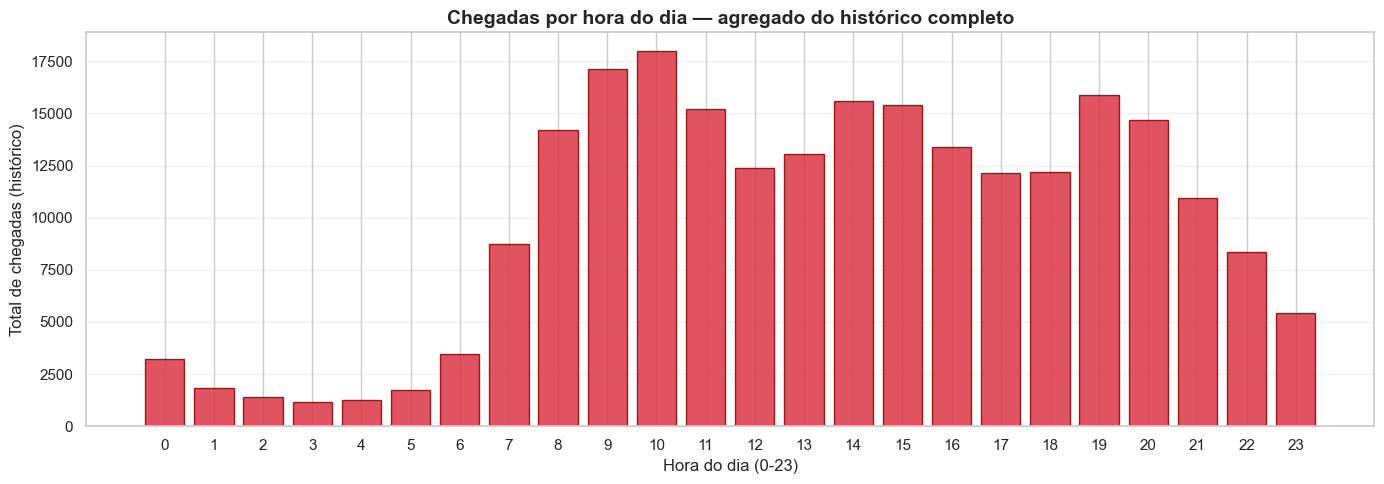


Hora de pico: 10h
Hora mais calma: 3h


In [8]:
# =============================================================================
# Distribuição de chegadas por hora do dia (agregado de todo o histórico)
# =============================================================================

chegadas_por_hora = df.groupby('hora_entrada').size().reset_index(name='chegadas')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(chegadas_por_hora['hora_entrada'], chegadas_por_hora['chegadas'],
              color='#dc3545', alpha=0.85, edgecolor='#8b0000')
ax.set_title('Chegadas por hora do dia — agregado do histórico completo',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hora do dia (0-23)')
ax.set_ylabel('Total de chegadas (histórico)')
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nHora de pico: {chegadas_por_hora.loc[chegadas_por_hora['chegadas'].idxmax(), 'hora_entrada']}h")
print(f"Hora mais calma: {chegadas_por_hora.loc[chegadas_por_hora['chegadas'].idxmin(), 'hora_entrada']}h")

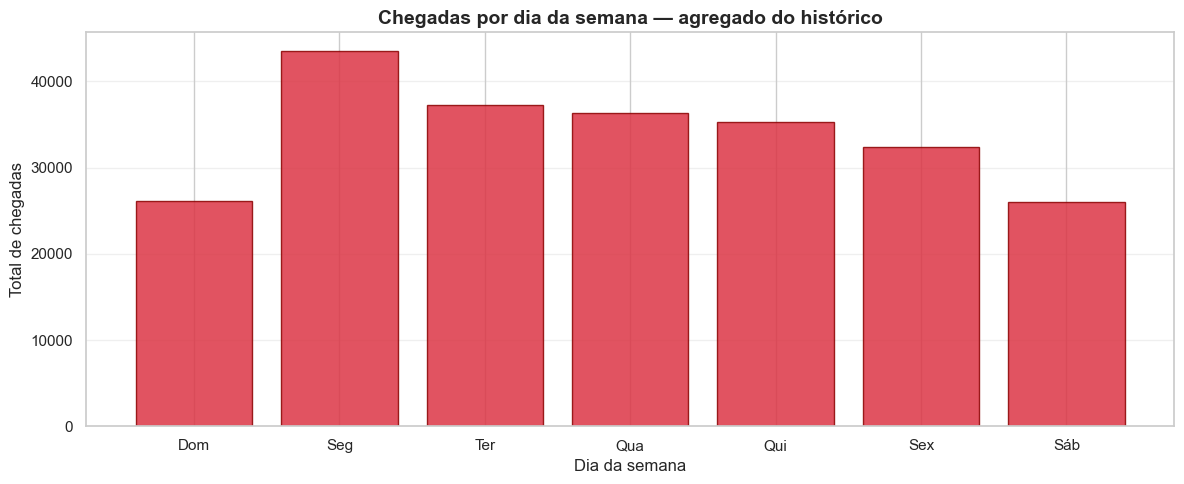


Volume por dia da semana:
nome_dia  chegadas
     Dom     26112
     Seg     43502
     Ter     37213
     Qua     36347
     Qui     35300
     Sex     32359
     Sáb     26031


In [9]:
# =============================================================================
# Distribuição por dia da semana
# =============================================================================

dias_semana_nomes = {1: 'Dom', 2: 'Seg', 3: 'Ter', 4: 'Qua', 5: 'Qui', 6: 'Sex', 7: 'Sáb'}

chegadas_por_dow = df.groupby('dia_semana').size().reset_index(name='chegadas')
chegadas_por_dow['nome_dia'] = chegadas_por_dow['dia_semana'].map(dias_semana_nomes)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(chegadas_por_dow['nome_dia'], chegadas_por_dow['chegadas'],
              color='#dc3545', alpha=0.85, edgecolor='#8b0000')
ax.set_title('Chegadas por dia da semana — agregado do histórico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Dia da semana')
ax.set_ylabel('Total de chegadas')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVolume por dia da semana:")
print(chegadas_por_dow[['nome_dia', 'chegadas']].to_string(index=False))

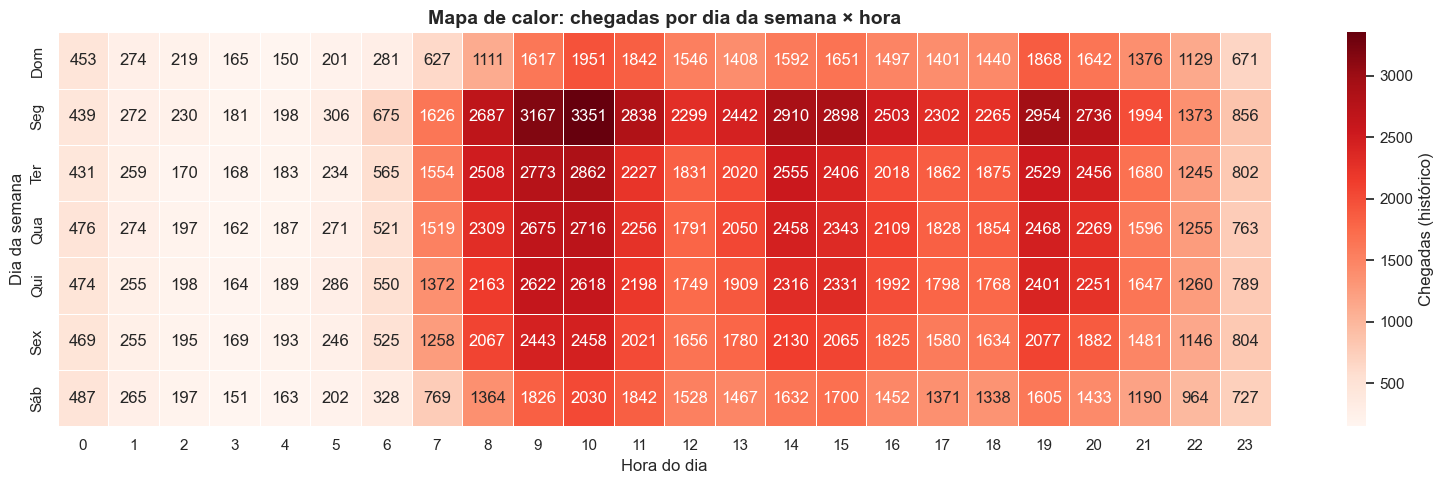

In [10]:
# =============================================================================
# Heatmap 24h x dia da semana — o gráfico que mais vai impressionar a diretoria
# =============================================================================

heatmap_data = df.groupby(['dia_semana', 'hora_entrada']).size().reset_index(name='chegadas')
heatmap_pivot = heatmap_data.pivot(index='dia_semana', columns='hora_entrada', values='chegadas')

# Renomeia linhas pro nome dos dias
heatmap_pivot.index = [dias_semana_nomes[d] for d in heatmap_pivot.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_pivot, cmap='Reds', annot=True, fmt='d',
            cbar_kws={'label': 'Chegadas (histórico)'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Mapa de calor: chegadas por dia da semana × hora',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Dia da semana')

plt.tight_layout()
plt.show()

In [11]:
# =============================================================================
# Salva o DataFrame em Parquet para os próximos notebooks não precisarem
# reconsultar o banco
# =============================================================================

import os
os.makedirs('../data', exist_ok=True)
output_path = '../data/ml_ps_historico_chegadas.parquet'
df.to_parquet(output_path, index=False, compression='snappy')

print(f"[OK] Dataset salvo em {output_path}")
print(f"     Tamanho: {os.path.getsize(output_path) / 1024**2:.1f} MB")
print(f"     Linhas:  {len(df):,}")
print()
print("=" * 70)
print("PRÓXIMO PASSO: Notebook 02 — Análise temporal aprofundada")
print("=" * 70)

[OK] Dataset salvo em ../data/ml_ps_historico_chegadas.parquet
     Tamanho: 15.1 MB
     Linhas:  236,864

PRÓXIMO PASSO: Notebook 02 — Análise temporal aprofundada
